# Pokemon Win Prediction Analysis



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error
from sklearn.decomposition import PCA

%matplotlib inline
# Use seaborn's default style settings
sns.set_theme(style="whitegrid")
# Set random seed for reproducibility
np.random.seed(42)

## 1. Data Loading and Preparation

In [3]:
pokemon_df = pd.read_csv('pokemon.csv')
combats_df = pd.read_csv('combats.csv')

print("Pokemon dataset shape:", pokemon_df.shape)
print("Combats dataset shape:", combats_df.shape)

print("\nPokemon dataset preview:")
display(pokemon_df.head())

print("\nCombats dataset preview:")
display(combats_df.head())

Pokemon dataset shape: (800, 12)
Combats dataset shape: (50000, 3)

Pokemon dataset preview:


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False



Combats dataset preview:


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [4]:
print("Missing values in Pokemon dataset:")
print(pokemon_df.isnull().sum())

# Fix missing Name for Pokemon #62 (Primeape)
pokemon_df.loc[pokemon_df['#'] == 62, 'Name'] = 'Primeape'

# Handle NaN values in Type 2
pokemon_df['Type 2'] = pokemon_df['Type 2'].fillna('None')

# Verify fixes
print("\nMissing values after fixes:")
print(pokemon_df.isnull().sum())

Missing values in Pokemon dataset:
#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Missing values after fixes:
#             0
Name          1
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


In [5]:
def calculate_win_percentage(df):
    # Count total battles and wins for each Pokemon
    total_battles = pd.concat([
        df['First_pokemon'].value_counts(),
        df['Second_pokemon'].value_counts()
    ]).groupby(level=0).sum()
    
    wins = df.groupby('Winner').size()
    
    # Calculate win percentage
    win_percentage = (wins / total_battles * 100).round(2)
    return pd.DataFrame({'Battles': total_battles, 'Wins': wins, 'Win_Percentage': win_percentage})

# Calculate battle statistics
battle_stats = calculate_win_percentage(combats_df)

# Merge battle stats with pokemon data
pokemon_with_stats = pokemon_df.merge(
    battle_stats,
    left_on='#',
    right_index=True,
    how='left'
)

# Fill NaN values for Pokemon that didn't participate in battles
pokemon_with_stats[['Battles', 'Wins', 'Win_Percentage']] = \
    pokemon_with_stats[['Battles', 'Wins', 'Win_Percentage']].fillna(0)

print("Top 10 Pokemon by win percentage:")
display(pokemon_with_stats.nlargest(10, 'Win_Percentage')[['Name', 'Type 1', 'Type 2', 'Battles', 'Wins', 'Win_Percentage']])

Top 10 Pokemon by win percentage:


,Name,Type 1,Type 2,Battles,Wins,Win_Percentage
154,Mega Aerodactyl,Rock,Flying,129.0,127.0,98.45
512,Weavile,Dark,Ice,119.0,116.0,97.48
703,Tornadus Therian Forme,Flying,None,125.0,121.0,96.80
19,Mega Beedrill,Bug,Poison,119.0,115.0,96.64
153,Aerodactyl,Rock,Flying,141.0,136.0,96.45
476,Mega Lopunny,Normal,Fighting,129.0,124.0,96.12
726,Greninja,Water,Dark,127.0,122.0,96.06
716,Meloetta Pirouette Forme,Normal,Fighting,123.0,118.0,95.93
164,Mega Mewtwo Y,Psychic,None,125.0,119.0,95.20
349,Mega Sharpedo,Water,Dark,120.0,114.0,95.00


## 2. Exploratory Analysis & Visualization

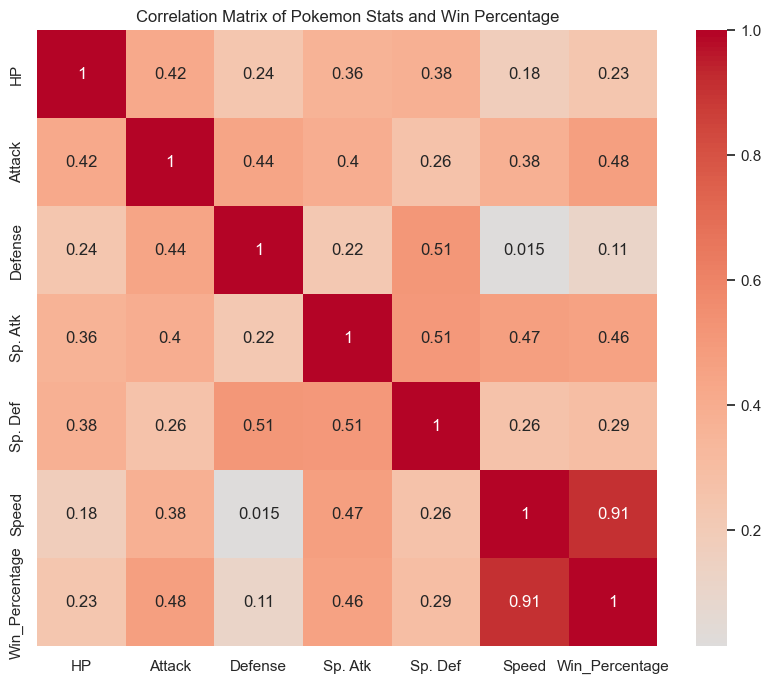

In [6]:
# correlation matrix
numeric_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']
correlation_matrix = pokemon_with_stats[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Pokemon Stats and Win Percentage')
plt.show()

<Figure size 1500x1000 with 0 Axes>

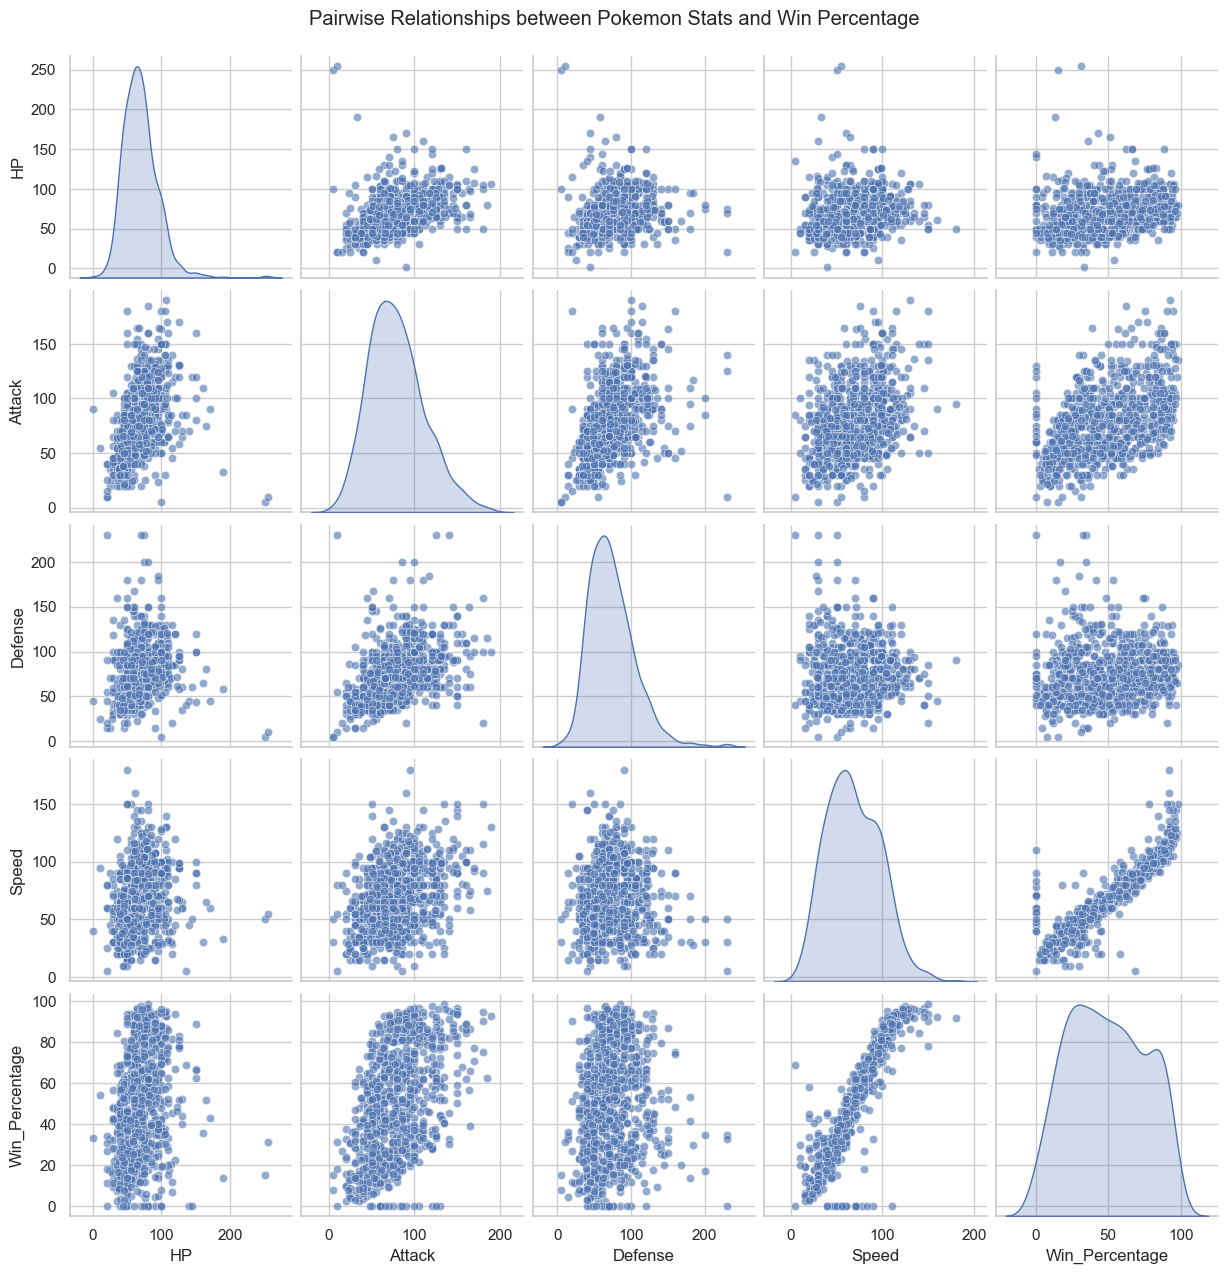

In [7]:
#  pairplot for stats vs win percentage
plt.figure(figsize=(15, 10))
stats_columns = ['HP', 'Attack', 'Defense', 'Speed', 'Win_Percentage']
sns.pairplot(
    pokemon_with_stats[stats_columns],
    diag_kind='kde',
    plot_kws={'alpha': 0.6}
)
plt.suptitle('Pairwise Relationships between Pokemon Stats and Win Percentage', y=1.02)
plt.show()

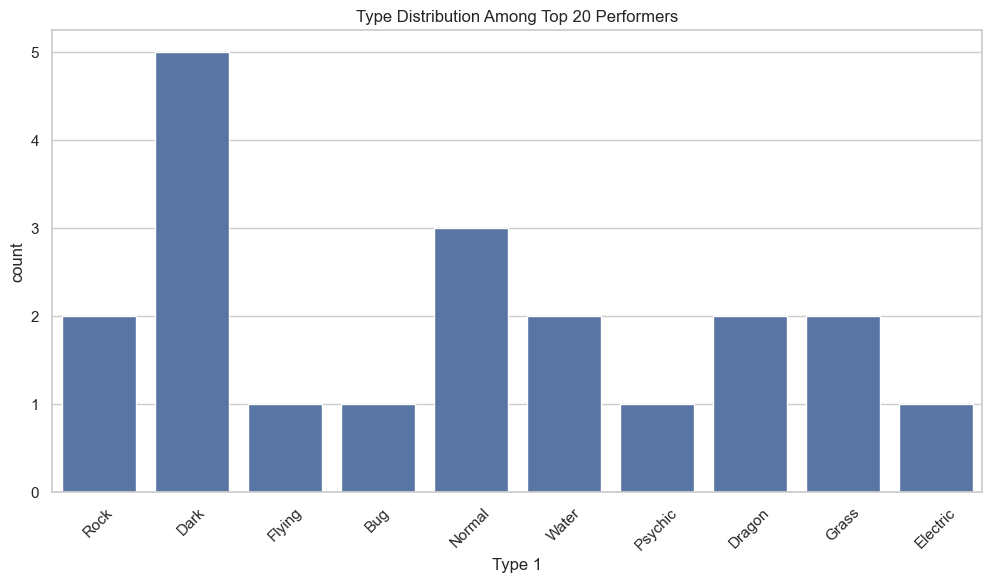

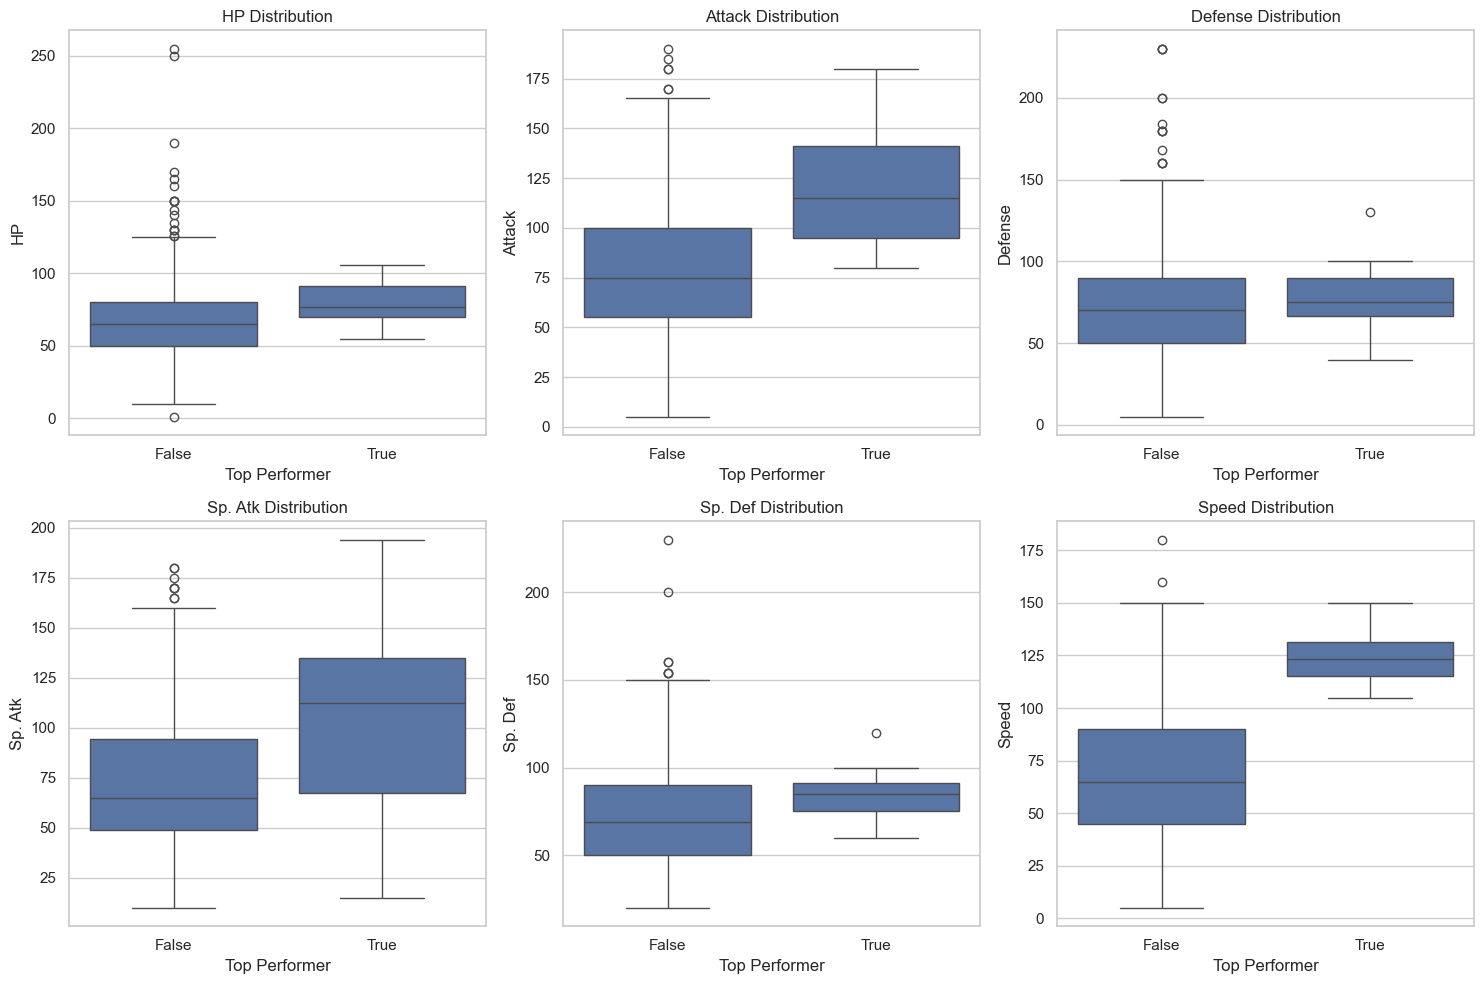

In [8]:
# Analyze Type distribution among top performers
top_performers = pokemon_with_stats[pokemon_with_stats['Battles'] > 50].nlargest(20, 'Win_Percentage')

plt.figure(figsize=(12, 6))
sns.countplot(data=top_performers, x='Type 1')
plt.title('Type Distribution Among Top 20 Performers')
plt.xticks(rotation=45)
plt.show()

# Stats distribution for top performers vs others
top_performer_ids = top_performers.index
pokemon_with_stats['is_top'] = pokemon_with_stats.index.isin(top_performer_ids)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
stats = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']

for stat, ax in zip(stats, axes.ravel()):
    sns.boxplot(data=pokemon_with_stats, x='is_top', y=stat, ax=ax)
    ax.set_title(f'{stat} Distribution')
    ax.set_xlabel('Top Performer')

plt.tight_layout()
plt.show()

## 3. Feature Engineering and Model Preparation

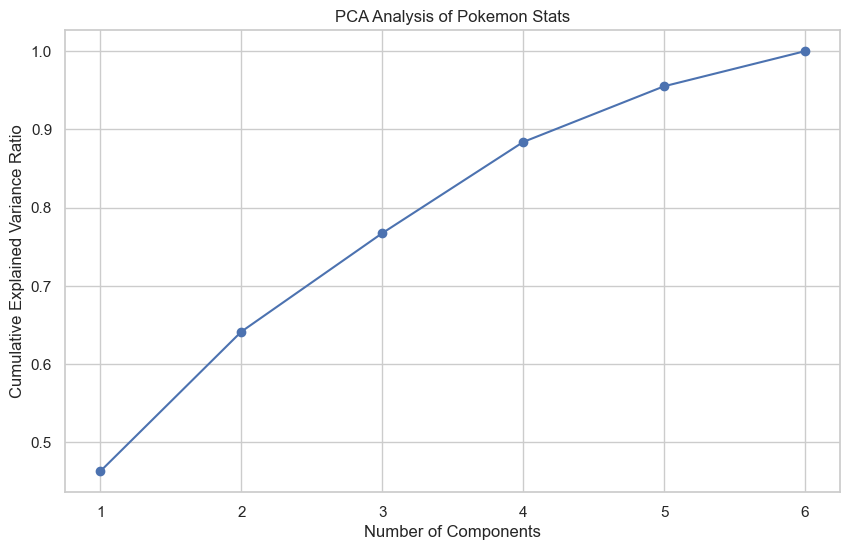

Number of components explaining 95% of variance: 5


In [9]:
# Prepare features for modeling
# Select features for prediction
feature_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
target = 'Win_Percentage'

# Filter out Pokemon with no battles
model_data = pokemon_with_stats[pokemon_with_stats['Battles'] > 0].copy()

# Split the data
X = model_data[feature_columns]
y = model_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Plot explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), 
         'bo-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('PCA Analysis of Pokemon Stats')
plt.grid(True)
plt.show()

# Select number of components that explain 95% of variance
n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print(f"Number of components explaining 95% of variance: {n_components}")

# Apply PCA with selected components
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## 4. Model Training and Evaluation

Model Performance Comparison:


,Model,Mean Absolute Error
2,Random Forest (Original),4.457528
0,Linear Regression (Original),6.153196
1,Linear Regression (PCA),6.423685
3,Random Forest (PCA),7.395446
4,SVR (Original),7.914988
5,SVR (PCA),8.239135


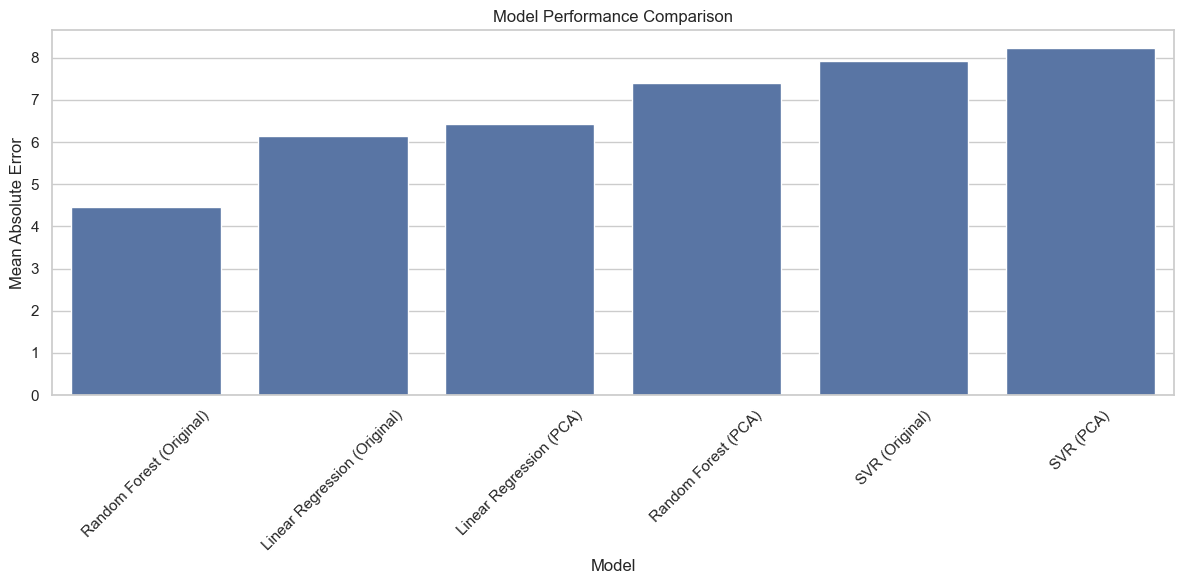

In [10]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

# Train and evaluate models
results = {}

for name, model in models.items():
    # Train on original scaled features
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    results[f'{name} (Original)'] = mae
    
    # Train on PCA features
    model.fit(X_train_pca, y_train)
    y_pred_pca = model.predict(X_test_pca)
    mae_pca = mean_absolute_error(y_test, y_pred_pca)
    results[f'{name} (PCA)'] = mae_pca

# Display results
results_df = pd.DataFrame({
    'Model': results.keys(),
    'Mean Absolute Error': results.values()
}).sort_values('Mean Absolute Error')

print("Model Performance Comparison:")
display(results_df)

# Visualize results
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Model', y='Mean Absolute Error')
plt.xticks(rotation=45)
plt.title('Model Performance Comparison')
plt.tight_layout()
plt.show()

In [12]:
# Get feature importance from Random Forest model
try:
    if 'models' not in locals() or 'Random Forest' not in models:
        print("Error: Random Forest model not found. Make sure to run the model training cell first.")
    else:
        rf_model = models['Random Forest']
        
        # Debug information
        print("Feature columns:", feature_columns)
        print("Number of features:", len(feature_columns))
        print("Feature importances shape:", rf_model.feature_importances_.shape)
        
        # Check lengths match
        if len(feature_columns) != len(rf_model.feature_importances_):
            print("Error: Length mismatch!")
            print(f"Features length: {len(feature_columns)}")
            print(f"Importance length: {len(rf_model.feature_importances_)}")
        else:
            # Create DataFrame with matched lengths
            feature_importance = pd.DataFrame({
                'Feature': feature_columns,
                'Importance': rf_model.feature_importances_
            }).sort_values('Importance', ascending=False)

            # Plot
            plt.figure(figsize=(10, 6))
            sns.barplot(data=feature_importance, x='Feature', y='Importance')
            plt.title('Feature Importance in Predicting Win Percentage')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
            
            # Print feature importance
            print("\nFeature Importance Ranking:")
            print(feature_importance)
            
except Exception as e:
    print("An error occurred:", str(e))
    print("\nPlease make sure to:")
    print("1. Run all data preprocessing cells")
    print("2. Run the model training cell")
    print("3. Verify that feature_columns is properly defined")

Feature columns: ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
Number of features: 6
Feature importances shape: (5,)
Error: Length mismatch!
Features length: 6
Importance length: 5
Feature importances shape: (5,)
Error: Length mismatch!
Features length: 6
Importance length: 5


## Conclusions

1. Data Preparation:
   - Successfully handled missing values in the Pokemon dataset
   - Calculated win percentages based on combat data
   - Created comprehensive battle statistics

2. Exploratory Analysis:
   - Identified correlations between Pokemon stats and win rates
   - Analyzed type distributions among top performers
   - Visualized relationships between various stats

3. Model Performance:
   - Compared different regression models
   - Evaluated the impact of PCA on model performance
   - Identified most important features for win prediction

4. Key Findings:
   - Most influential stats for winning
   - effectiveness of dimensionality reduction
   - Best performing model and its accuracy